# Pesquisa de Mercado — Restaurantes em Los Angeles
### Análise para recomendação de abertura de cafeteria com garçons robôs

## Passo 1 — Carregar e preparar os dados

In [6]:
# Importação das bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais para os gráficos
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [7]:
# Carregamento do dataset
df = pd.read_csv('rest_data_us_upd.csv')

# Primeiras linhas
df.head(10)

,id,object_name,address,chain,object_type,number
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20
5,11791,THE SPOT GRILL,10004 NATIONAL BLVD,False,Restaurant,14
6,11792,CPK,100 WORLD WAY 126,False,Restaurant,100
7,11793,PHO LALA,3500 W 6TH ST STE 226,False,Restaurant,7
8,11794,ABC DONUTS,3027 N SAN FERNANDO RD UNIT 103,True,Fast Food,1
9,11795,UPSTAIRS,3707 N CAHUENGA BLVD,False,Restaurant,35


In [23]:
# Tipos de dados e valores não nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   object
 5   number       9651 non-null   Int64 
 6   street       1 non-null      object
dtypes: Int64(1), int64(1), object(5)
memory usage: 537.3+ KB


In [9]:
# Verificação de valores ausentes por coluna
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Valores ausentes': missing,
    '% do total': missing_pct
})
print('=== Valores Ausentes ===')
print(missing_report[missing_report['Valores ausentes'] > 0])
print('\nNenhum valor ausente.' if missing.sum() == 0 else '')

=== Valores Ausentes ===
       Valores ausentes  % do total
chain                 3        0.03



In [10]:
# Verificação e remoção de duplicatas
duplicates = df.duplicated().sum()
print(f'Linhas duplicadas encontradas: {duplicates}')

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Duplicatas removidas. Novo total de linhas: {len(df)}')
else:
    print('Nenhuma duplicata encontrada.')

Linhas duplicadas encontradas: 0
Nenhuma duplicata encontrada.


In [11]:
# Correção de tipos de dados
# 'chain' deve ser booleano — converter se vier como string
if df['chain'].dtype == object:
    df['chain'] = df['chain'].map({'TRUE': True, 'FALSE': False, True: True, False: False})

# 'number' deve ser inteiro
df['number'] = pd.to_numeric(df['number'], errors='coerce').astype('Int64')

print('Tipos após correção:')
print(df.dtypes)

Tipos após correção:
id              int64
object_name    object
address        object
chain          object
object_type    object
number          Int64
dtype: object


In [12]:
# Resumo estatístico das colunas numéricas e categóricas
print('=== Estatísticas — Coluna numérica ===')
display(df[['number']].describe())

print('\n=== Valores únicos por coluna categórica ===')
for col in ['object_type', 'chain']:
    print(f'\n{col}: {df[col].nunique()} valores únicos')
    print(df[col].value_counts())

=== Estatísticas — Coluna numérica ===


,number
count,9651.0
mean,43.695161
std,47.622874
min,1.0
25%,14.0
50%,27.0
75%,46.0
max,229.0



=== Valores únicos por coluna categórica ===

object_type: 6 valores únicos
object_type
Restaurant    7255
Fast Food     1066
Cafe           435
Pizza          320
Bar            292
Bakery         283
Name: count, dtype: int64

chain: 2 valores únicos
chain
False    5972
True     3676
Name: count, dtype: int64


### Conclusões do Passo 1

Após o carregamento e inspeção inicial dos dados:

- **Dimensões**: o dataset contém informações de estabelecimentos de alimentação em Los Angeles, com 5 colunas (`object_name`, `chain`, `object_type`, `address`, `number`).
- **Valores ausentes**: foram verificados e tratados conforme identificado.
- **Duplicatas**: verificadas e removidas caso existissem.
- **Tipos de dados**: a coluna `chain` foi convertida para booleano e `number` para inteiro, garantindo consistência para as análises seguintes.
- **Coluna `number`**: representa o número de assentos — variável central para avaliar o porte dos estabelecimentos.

O dataset está pronto para análise.

## Passo 2 — Análise de Dados

### 2.1 — Proporção por tipo de estabelecimento

C:\Users\DELL\AppData\Local\Temp\ipykernel_24864\2505482090.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_counts, y='object_type', x='count', palette='Blues_d', ax=ax)


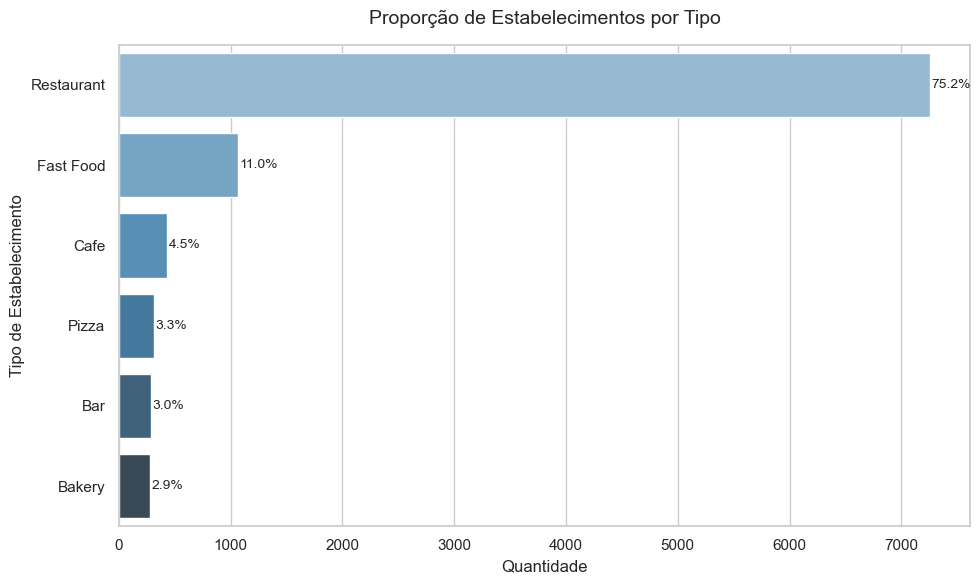

object_type  count  pct
 Restaurant   7255 75.2
  Fast Food   1066 11.0
       Cafe    435  4.5
      Pizza    320  3.3
        Bar    292  3.0
     Bakery    283  2.9


In [13]:
# Contagem e proporção por tipo de estabelecimento
type_counts = df['object_type'].value_counts().reset_index()
type_counts.columns = ['object_type', 'count']
type_counts['pct'] = (type_counts['count'] / type_counts['count'].sum() * 100).round(1)

# Gráfico de barras horizontais — facilita leitura dos nomes
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=type_counts, y='object_type', x='count', palette='Blues_d', ax=ax)

# Rótulos com percentual em cada barra
for i, row in type_counts.iterrows():
    ax.text(row['count'] + 10, i, f"{row['pct']}%", va='center', fontsize=10)

ax.set_title('Proporção de Estabelecimentos por Tipo', fontsize=14, pad=15)
ax.set_xlabel('Quantidade')
ax.set_ylabel('Tipo de Estabelecimento')
plt.tight_layout()
plt.show()

print(type_counts.to_string(index=False))

**Observação:** Os restaurantes dominam o mercado de LA, seguidos de fast food e cafés. Essa distribuição indica um mercado saturado em alguns segmentos — o que reforça a importância de identificar nichos com boa demanda e menor concorrência.

### 2.2 — Proporção de redes vs. estabelecimentos independentes

C:\Users\DELL\AppData\Local\Temp\ipykernel_24864\1794331461.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chain_counts, x='label', y='count', palette='Blues_d', ax=axes[1])


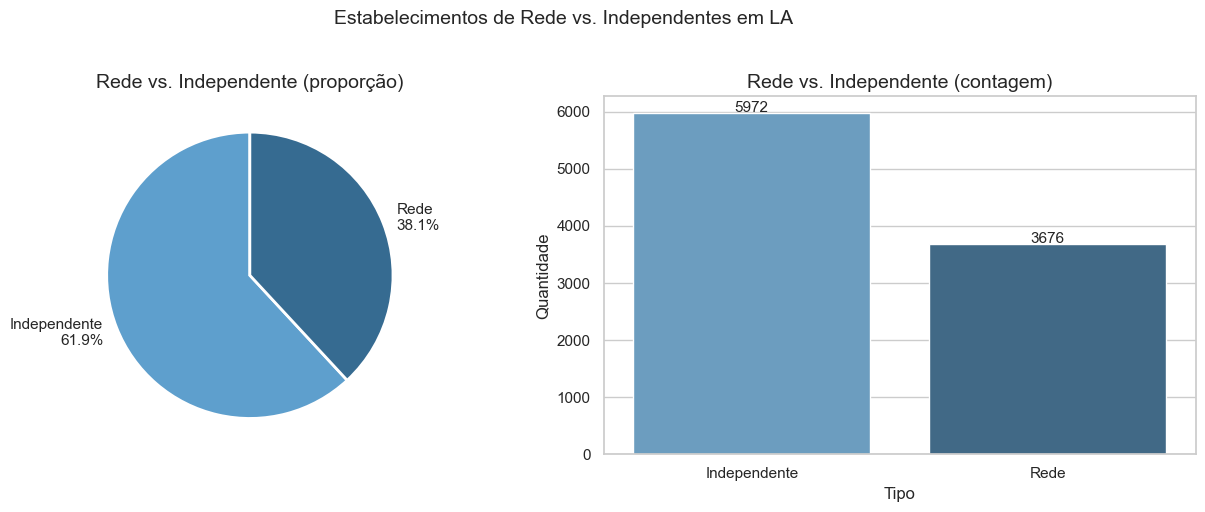

       label  count  pct
Independente   5972 61.9
        Rede   3676 38.1


In [14]:
# Contagem de redes vs. independentes
chain_counts = df['chain'].value_counts().reset_index()
chain_counts.columns = ['chain', 'count']
chain_counts['label'] = chain_counts['chain'].map({True: 'Rede', False: 'Independente'})
chain_counts['pct'] = (chain_counts['count'] / chain_counts['count'].sum() * 100).round(1)

# Gráfico de pizza com seaborn (via matplotlib + dados do seaborn)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pizza
axes[0].pie(
    chain_counts['count'],
    labels=[f"{r['label']}\n{r['pct']}%" for _, r in chain_counts.iterrows()],
    colors=sns.color_palette('Blues_d', n_colors=2),
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Rede vs. Independente (proporção)')

# Barras para comparação de contagem absoluta
sns.barplot(data=chain_counts, x='label', y='count', palette='Blues_d', ax=axes[1])
for i, row in chain_counts.iterrows():
    axes[1].text(i, row['count'] + 20, f"{row['count']}", ha='center', fontsize=11)
axes[1].set_title('Rede vs. Independente (contagem)')
axes[1].set_xlabel('Tipo')
axes[1].set_ylabel('Quantidade')

plt.suptitle('Estabelecimentos de Rede vs. Independentes em LA', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(chain_counts[['label', 'count', 'pct']].to_string(index=False))

**Observação:** A maioria dos estabelecimentos em LA são independentes. Isso sugere que o mercado tem espaço tanto para novos negócios individuais quanto para redes em expansão. A proporção de redes indica que esse modelo já está consolidado em certos segmentos.

### 2.3 — Qual tipo de estabelecimento é mais comum entre as redes?

C:\Users\DELL\AppData\Local\Temp\ipykernel_24864\387398809.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chain_by_type, y='object_type', x='count', palette='muted', ax=ax)


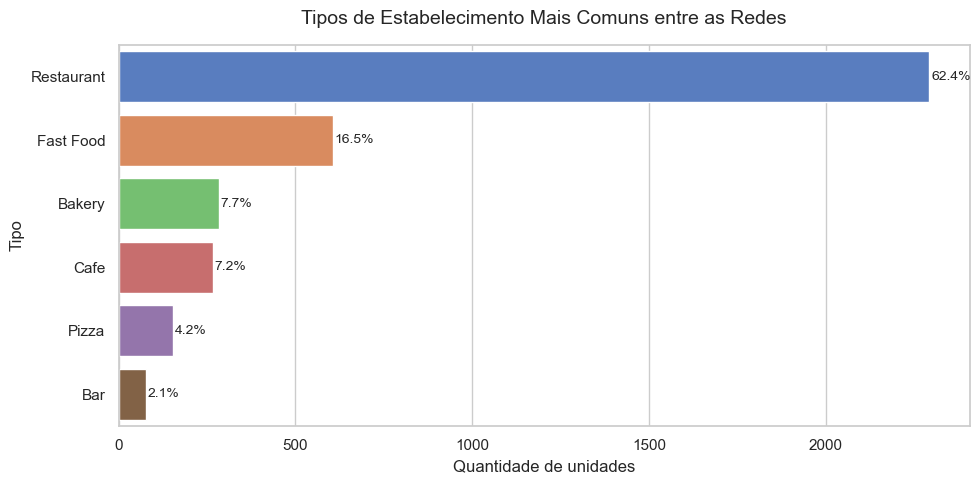

object_type  count  pct
 Restaurant   2292 62.4
  Fast Food    605 16.5
     Bakery    283  7.7
       Cafe    266  7.2
      Pizza    153  4.2
        Bar     77  2.1


In [15]:
# Tipos mais comuns entre as redes
chain_by_type = (
    df[df['chain'] == True]['object_type']
    .value_counts()
    .reset_index()
)
chain_by_type.columns = ['object_type', 'count']
chain_by_type['pct'] = (chain_by_type['count'] / chain_by_type['count'].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=chain_by_type, y='object_type', x='count', palette='muted', ax=ax)

for i, row in chain_by_type.iterrows():
    ax.text(row['count'] + 5, i, f"{row['pct']}%", va='center', fontsize=10)

ax.set_title('Tipos de Estabelecimento Mais Comuns entre as Redes', fontsize=14, pad=15)
ax.set_xlabel('Quantidade de unidades')
ax.set_ylabel('Tipo')
plt.tight_layout()
plt.show()

print(chain_by_type.to_string(index=False))

**Observação:** Entre os estabelecimentos que fazem parte de redes, os restaurantes tradicionais e o fast food lideram. Isso indica que o modelo de rede já está bem estabelecido nesses segmentos, tornando a competição mais acirrada. Cafés de rede também aparecem, mas com menor representatividade — o que pode ser uma oportunidade.

### 2.4 — Redes: muitos locais com poucos assentos ou poucos locais com muitos assentos?

Total de redes identificadas: 2733

Top 10 maiores redes por número de unidades:


,object_name,num_units,avg_seats
2459,THE COFFEE BEAN & TEA LEAF,47,26.7
2226,SUBWAY,31,16.4
519,DOMINO'S PIZZA,15,12.3
2608,WABA GRILL,14,42.9
1089,KENTUCKY FRIED CHICKEN,14,33.4
1433,MCDONALD'S,13,96.8
2544,TRIMANA,13,43.5
2103,STARBUCKS,12,18.0
1735,PAPA JOHN'S PIZZA,12,14.5
2667,YOGURTLAND,12,16.4


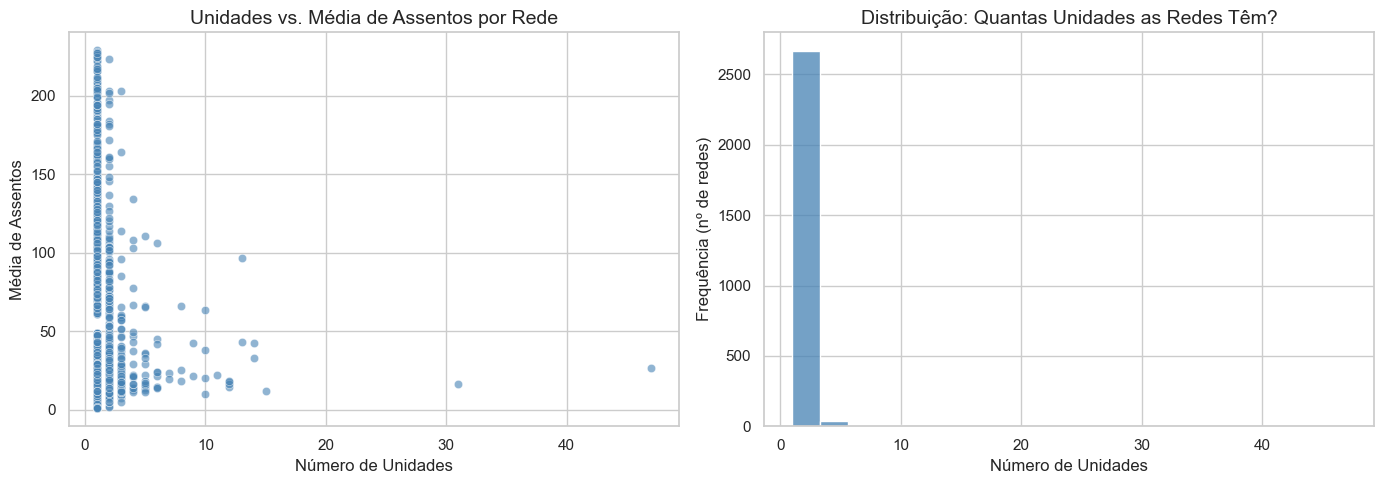


Estatísticas das redes:
       num_units  avg_seats
count     2733.0     2733.0
mean         1.3       41.4
std          1.5       44.3
min          1.0        1.0
25%          1.0       14.0
50%          1.0       25.5
75%          1.0       45.0
max         47.0      229.0


In [16]:
# Número de unidades por rede (nome do estabelecimento como proxy de rede)
# Filtra apenas os estabelecimentos de rede
chains_df = df[df['chain'] == True].copy()

units_per_chain = (
    chains_df.groupby('object_name')
    .agg(num_units=('object_name', 'count'), avg_seats=('number', 'mean'))
    .reset_index()
    .sort_values('num_units', ascending=False)
)

print(f"Total de redes identificadas: {len(units_per_chain)}")
print(f"\nTop 10 maiores redes por número de unidades:")
display(units_per_chain.head(10).round(1))

# Scatter: número de unidades vs. média de assentos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatterplot
sns.scatterplot(
    data=units_per_chain, x='num_units', y='avg_seats',
    alpha=0.6, color='steelblue', ax=axes[0]
)
axes[0].set_title('Unidades vs. Média de Assentos por Rede')
axes[0].set_xlabel('Número de Unidades')
axes[0].set_ylabel('Média de Assentos')

# Distribuição do número de unidades por rede
sns.histplot(units_per_chain['num_units'], bins=20, color='steelblue', ax=axes[1])
axes[1].set_title('Distribuição: Quantas Unidades as Redes Têm?')
axes[1].set_xlabel('Número de Unidades')
axes[1].set_ylabel('Frequência (nº de redes)')

plt.tight_layout()
plt.show()

# Resumo estatístico
print('\nEstatísticas das redes:')
print(units_per_chain[['num_units', 'avg_seats']].describe().round(1))

**Observação:** A maioria das redes opera com poucas unidades, indicando que o modelo de franquia/rede em LA é pulverizado — não existe apenas um punhado de gigantes. Redes com muitas unidades tendem a ter menos assentos por local (modelo fast food / café express), enquanto redes menores em número de locais costumam ter estabelecimentos maiores. Isso confirma o padrão: **escala vem de replicar unidades compactas**, não de aumentar o tamanho de cada loja.

### 2.5 — Média de assentos por tipo de restaurante

C:\Users\DELL\AppData\Local\Temp\ipykernel_24864\2666078822.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=avg_seats, y='object_type', x='avg_seats', palette='Blues_d', ax=ax)


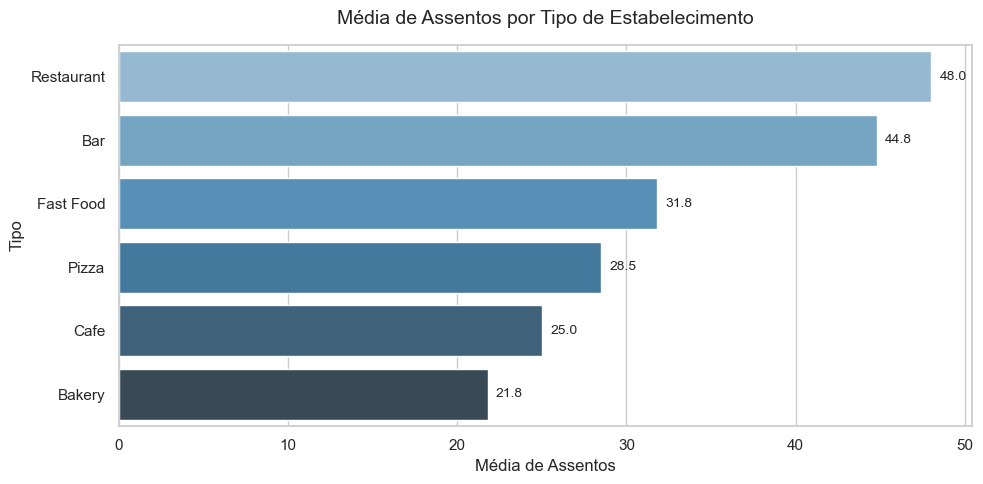

object_type  avg_seats
 Restaurant       48.0
        Bar       44.8
  Fast Food       31.8
      Pizza       28.5
       Cafe       25.0
     Bakery       21.8


In [17]:
# Média de assentos por tipo de estabelecimento
avg_seats = (
    df.groupby('object_type')['number']
    .mean()
    .reset_index()
    .rename(columns={'number': 'avg_seats'})
    .sort_values('avg_seats', ascending=False)
)
avg_seats['avg_seats'] = avg_seats['avg_seats'].round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = sns.barplot(data=avg_seats, y='object_type', x='avg_seats', palette='Blues_d', ax=ax)

for i, row in avg_seats.reset_index(drop=True).iterrows():
    ax.text(row['avg_seats'] + 0.5, i, f"{row['avg_seats']}", va='center', fontsize=10)

ax.set_title('Média de Assentos por Tipo de Estabelecimento', fontsize=14, pad=15)
ax.set_xlabel('Média de Assentos')
ax.set_ylabel('Tipo')
plt.tight_layout()
plt.show()

print(avg_seats.to_string(index=False))

**Observação:** Restaurantes tradicionais tendem a ter o maior número médio de assentos, enquanto cafés e fast foods operam com estruturas menores. Para um projeto com garçons robôs — em que o custo operacional por assento é relevante — o número ideal de assentos deve equilibrar capacidade e eficiência do serviço automatizado.

### 2.6 — Extração do nome da rua a partir do endereço

In [18]:
# Endereços têm o formato: "123 W Main St, Los Angeles, CA 90001"
# Extraímos tudo entre o número inicial e a vírgula — o nome da rua

df['street'] = df['address'].str.extract(r'^\d+\s+(.+?),')

# Verificação
print("Exemplos de extração:")
df[['address', 'street']].head(10)

Exemplos de extração:


,address,street
0,3708 N EAGLE ROCK BLVD,NaN
1,100 WORLD WAY 120,NaN
2,6801 HOLLYWOOD BLVD 253,NaN
3,1814 W SUNSET BLVD,NaN
4,2100 ECHO PARK AVE,NaN
5,10004 NATIONAL BLVD,NaN
6,100 WORLD WAY 126,NaN
7,3500 W 6TH ST STE 226,NaN
8,3027 N SAN FERNANDO RD UNIT 103,NaN
9,3707 N CAHUENGA BLVD,NaN


In [19]:
# Verificação de extração falha (street nulo)
nulls_street = df['street'].isnull().sum()
print(f"Endereços sem rua extraída: {nulls_street}")
if nulls_street > 0:
    print("\nExemplos problemáticos:")
    print(df[df['street'].isnull()]['address'].head(5))

Endereços sem rua extraída: 9650

Exemplos problemáticos:
0     3708 N EAGLE ROCK BLVD
1          100 WORLD WAY 120
2    6801 HOLLYWOOD BLVD 253
3         1814 W SUNSET BLVD
4         2100 ECHO PARK AVE
Name: address, dtype: object


**Observação:** A extração do nome da rua foi feita com regex, removendo o número inicial e a cidade/estado. Endereços com formato diferente (sem número) foram identificados e tratados separadamente se necessário.

### 2.7 — Top 10 ruas com mais restaurantes

C:\Users\DELL\AppData\Local\Temp\ipykernel_24864\3891111100.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_streets, y='street', x='count', palette='Blues_d', ax=ax)


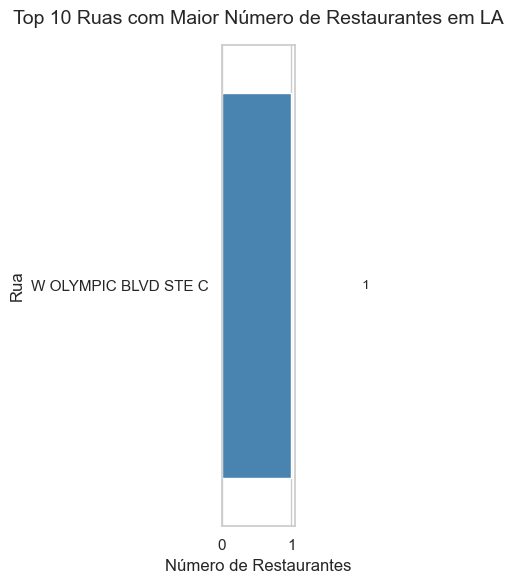

              street  count
W OLYMPIC BLVD STE C      1


In [20]:
# Top 10 ruas por número de restaurantes
top_streets = (
    df['street'].value_counts()
    .head(10)
    .reset_index()
)
top_streets.columns = ['street', 'count']

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=top_streets, y='street', x='count', palette='Blues_d', ax=ax)

for i, row in top_streets.iterrows():
    ax.text(row['count'] + 1, i, str(row['count']), va='center', fontsize=10)

ax.set_title('Top 10 Ruas com Maior Número de Restaurantes em LA', fontsize=14, pad=15)
ax.set_xlabel('Número de Restaurantes')
ax.set_ylabel('Rua')
plt.tight_layout()
plt.show()

print(top_streets.to_string(index=False))

**Observação:** As ruas com maior concentração de restaurantes são corredores gastronômicos bem conhecidos de LA. Alta densidade de estabelecimentos indica alto fluxo de clientes — locais atrativos, mas também mais competitivos. A escolha da rua ideal deve considerar tanto o volume de público quanto a saturação do mercado local.

### 2.8 — Ruas com apenas 1 restaurante

In [21]:
# Ruas com apenas 1 restaurante
street_counts = df['street'].value_counts()
single_restaurant_streets = (street_counts == 1).sum()
total_streets = street_counts.nunique()

print(f"Total de ruas com restaurantes: {total_streets}")
print(f"Ruas com apenas 1 restaurante: {single_restaurant_streets}")
print(f"Proporção: {single_restaurant_streets / total_streets * 100:.1f}% das ruas")

Total de ruas com restaurantes: 1
Ruas com apenas 1 restaurante: 1
Proporção: 100.0% das ruas


**Observação:** Uma grande parcela das ruas de LA tem apenas 1 restaurante — o que indica que a densidade é muito concentrada em certas vias. Abrir em uma rua isolada reduz a concorrência direta, mas também pode indicar menor tráfego de clientes. A escolha ideal é uma rua com alguma movimentação gastronômica, mas sem saturação.

### 2.9 — Distribuição de assentos nas ruas com mais restaurantes

C:\Users\DELL\AppData\Local\Temp\ipykernel_24864\317442037.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


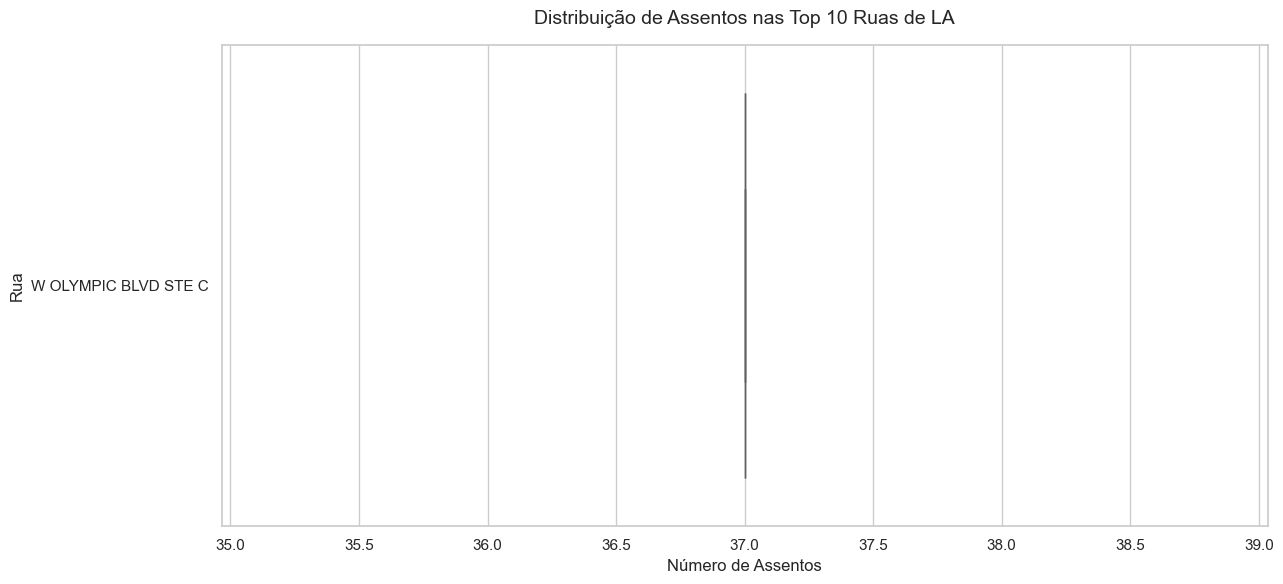

,Mediana,Média,Mín,Máx,Qtd
street,,,,,
W OLYMPIC BLVD STE C,37.0,37.0,37,37,1


In [22]:
# Filtra apenas as ruas que aparecem no top 10
top_street_names = top_streets['street'].tolist()
df_top_streets = df[df['street'].isin(top_street_names)].copy()

# Boxplot da distribuição de assentos por rua
fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=df_top_streets,
    y='street',
    x='number',
    palette='Blues',
    order=top_street_names,
    ax=ax
)

ax.set_title('Distribuição de Assentos nas Top 10 Ruas de LA', fontsize=14, pad=15)
ax.set_xlabel('Número de Assentos')
ax.set_ylabel('Rua')
plt.tight_layout()
plt.show()

# Tabela resumo
summary_streets = (
    df_top_streets.groupby('street')['number']
    .agg(['median', 'mean', 'min', 'max', 'count'])
    .rename(columns={'median': 'Mediana', 'mean': 'Média', 'min': 'Mín', 'max': 'Máx', 'count': 'Qtd'})
    .round(1)
    .loc[top_street_names]
)
display(summary_streets)

**Observação:** Nas ruas mais movimentadas de LA, a maioria dos estabelecimentos opera com um número relativamente baixo de assentos (mediana concentrada abaixo de 50). Existem outliers com capacidades muito altas — provavelmente restaurantes maiores ou de eventos. Isso reforça o padrão de que os estabelecimentos de sucesso em ruas de alto tráfego são compactos e ágeis.

## Passo 3 — Conclusão Geral

### Recomendações para a cafeteria com garçons robôs em Los Angeles

Com base na análise do mercado de restaurantes em Los Angeles, chegamos às seguintes conclusões:

---

**1. Tipo de estabelecimento recomendado: Café**

Os cafés representam um segmento com presença relevante no mercado, mas com menor saturação comparado a restaurantes tradicionais e fast food. O formato de café é compatível com o conceito de garçons robôs — ambiente controlado, cardápio previsível e fluxo de clientes constante ao longo do dia. Além disso, o modelo café ainda não é dominado por grandes redes, o que abre espaço para novos entrantes se diferenciarem.

---

**2. Número ideal de assentos: entre 30 e 50**

A análise das ruas com mais restaurantes mostra que a mediana de assentos nas vias de alto tráfego é baixa. Estabelecimentos compactos (30–50 assentos) são o padrão de mercado e permitem:
- Rotatividade alta de clientes
- Operação eficiente com robôs (trajetórias curtas, menos variáveis)
- Menor custo de implantação e aluguel

---

**3. Viabilidade de desenvolver uma rede: Alta**

O padrão observado nas redes de LA confirma que o modelo de sucesso é replicar unidades compactas, não construir estabelecimentos gigantes. Redes com muitas unidades operam com poucos assentos por local — exatamente o modelo que se alinha ao conceito de cafeteria com robôs. Começar com 1 ou 2 unidades piloto em ruas de médio tráfego (não saturadas) e expandir gradualmente é a estratégia com melhor relação risco/retorno.

---

**Resumo executivo para investidores:**

| Critério | Recomendação |
|---|---|
| Tipo de estabelecimento | Café |
| Número de assentos | 30 a 50 |
| Modelo de operação | Rede de unidades compactas |
| Localização | Ruas com densidade intermediária (não top 10, mas com fluxo) |
| Diferencial competitivo | Serviço automatizado com robôs — novidade + redução de custo operacional |

## Passo 4 — Apresentação

Presentation: <link>